# Kiểm định giả thuyết về cường độ chịu nén bê tông

## Hai câu hỏi nghiên cứu chính

**Câu hỏi 1.** Trong các cấp phối có dữ liệu ở cả **7 và 28 ngày**, cường độ chịu nén **trung bình tăng bao nhiêu MPa** và mức chênh lệch đó có khác 0 không? Ghép theo cấp phối, đặt $d = \text{MPa}_{28} - \text{MPa}_{7}$; $H_0: \mu_d = 0$, $H_1: \mu_d \ne 0$. Kiểm định chính: **paired t-test**; báo cáo KTC 95% của mức tăng.

**Câu hỏi 2.** Ở **28 ngày**, cường độ chịu nén trung bình **quan sát được** có khác nhau giữa bốn nhóm *Không SCM, Chỉ xỉ, Chỉ tro bay, Cả hai* không? $H_0: \mu_1 = \mu_2 = \mu_3 = \mu_4$; $H_1$: ít nhất một trung bình khác. Kiểm định chính: **Welch ANOVA**, sau đó **Games–Howell** cho sáu cặp.

Đơn vị phân tích là cấp phối gần trùng đã gộp theo vật liệu. Phân tích vùng xi măng chung chỉ là kiểm tra **thăm dò**; Chi-square bổ sung về cấu trúc cấp phối. Phần diễn giải đầy đủ nằm trong `report/hypothesis_tests_report.md` và Word/PDF.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image

here = Path.cwd().resolve()
matches = [p for p in [here, *here.parents] if (p / "analysis/hypothesis_tests.py").is_file()]
if not matches:
    matches = [p for p in here.glob("*/") if (p / "analysis/hypothesis_tests.py").is_file()]
if not matches:
    raise FileNotFoundError("Mở thư mục gốc của gói trong VS Code/Jupyter rồi chạy notebook.")
root = matches[0]
sys.path.insert(0, str(root / "analysis"))
import hypothesis_tests as ht
print("Gói:", root.name, "| CSV:", ht.DATA_PATH.is_file())


Gói: hypothesis_tests_quan_v5 | CSV: True


## 3.1. Cơ sở lý thuyết

### 3.1.1. Quy trình chung

Một phép kiểm định gồm: câu hỏi → đơn vị phân tích → giả thuyết H₀/H₁ → điều kiện áp dụng → thống kê kiểm định và p-value → độ lớn chênh lệch và kết luận. Chọn mức ý nghĩa **α = 0,05**. Nếu p < α, bác bỏ H₀; nếu p ≥ α, chưa đủ bằng chứng bác bỏ H₀. P-value phản ánh mức độ bất tương thích với H₀ trong mô hình kiểm định, còn ý nghĩa thực tiễn được đọc qua MPa và khoảng tin cậy.

**Khoảng tin cậy 95% (CI)** thể hiện độ bất định của ước lượng theo phương pháp lấy mẫu. **SD** mô tả mức phân tán giữa các quan sát. **Kích thước hiệu ứng** mô tả độ lớn khác biệt; không thể thay thế nó bằng một p-value nhỏ.

### 3.1.2. t-test: so sánh hai trung bình

**Hai mẫu độc lập — Welch t-test.** Dùng khi mỗi quan sát chỉ thuộc một trong hai nhóm và các đơn vị quan sát độc lập. Ký hiệu $\bar x_j$, $s_j$, $n_j$ lần lượt là trung bình, độ lệch chuẩn và số quan sát nhóm j:

$$t=\frac{\bar x_1-\bar x_2}{\sqrt{s_1^2/n_1+s_2^2/n_2}},\qquad
\nu=\frac{(s_1^2/n_1+s_2^2/n_2)^2}{(s_1^2/n_1)^2/(n_1-1)+(s_2^2/n_2)^2/(n_2-1)}.$$

Giả thuyết hai phía: $H_0:\mu_1=\mu_2$ và $H_1:\mu_1\ne\mu_2$. Welch cho phép phương sai và số quan sát hai nhóm khác nhau. Với mẫu nhỏ, cần xem hình dạng phân phối và ngoại lai.

**Ví dụ giả lập:** hai nhóm độc lập đều có n = 20; trung bình 32 và 36 MPa, SD là 5 và 6 MPa. Khi đó $t=(32-36)/\sqrt{25/20+36/20}\approx-2,29$. Ví dụ chỉ minh họa công thức; đây không phải số liệu của dự án.

**Hai mẫu ghép — paired t-test.** Dùng khi có quy tắc ghép cặp hợp lý. Đặt $d_i=x_{i,28}-x_{i,7}$:

$$t=\frac{\bar d}{s_d/\sqrt n},\quad df=n-1,\qquad
CI_{95\%}=\bar d\pm t_{0,975;n-1}\frac{s_d}{\sqrt n}.$$

Các cặp cần đủ độc lập với nhau. Điều kiện phân phối được xét trên **chênh lệch d**, vì kiểm định thực chất là t-test một mẫu trên d. Cohen’s $d_z=\bar d/s_d$ chuẩn hóa chênh lệch theo độ lệch chuẩn của d.

**Ví dụ giả lập:** năm chênh lệch [2, 3, 4, 5, 6] có $\bar d=4$, $s_d=\sqrt{2,5}$, nên $t=5,657$ với 4 bậc tự do. Trong bài, ghép theo thành phần cấp phối và đo cường độ của các mẫu ở hai tuổi; không cần coi đó là cùng một mẫu vật được nén hai lần.

### 3.1.3. Chi-square: liên hệ giữa hai biến phân loại

$H_0$: hai biến phân loại độc lập; $H_1$: chúng có liên hệ. Với bảng r hàng, c cột và tổng N:

$$E_{ij}=\frac{n_{i\cdot}n_{\cdot j}}{N},\qquad
\chi^2=\sum_{i=1}^{r}\sum_{j=1}^{c}\frac{(O_{ij}-E_{ij})^2}{E_{ij}},\qquad df=(r-1)(c-1).$$

$O_{ij}$ là số đếm quan sát; $E_{ij}$ là số đếm kỳ vọng nếu H₀ đúng. Mỗi đơn vị chỉ đóng góp vào một ô, các đơn vị độc lập, và tần số kỳ vọng phải đủ lớn. Ở phần minh họa của bài, mọi tần số kỳ vọng đều ít nhất bằng 5. Hệ số Cramér’s $V=\sqrt{\chi^2/[N\min(r-1,c-1)]}$ mô tả độ lớn liên hệ.

**Ví dụ giả lập:** hai nhóm A/B có số lượng đạt/không đạt lần lượt [30, 20] và [20, 30]. Bốn tần số kỳ vọng đều bằng 25; χ² = 4 và df = 1 khi không dùng hiệu chỉnh liên tục. Đây là một bảng số đếm, không dùng trực tiếp các giá trị MPa làm tần số.

### 3.1.4. ANOVA: so sánh từ ba trung bình

$H_0:\mu_1=\cdots=\mu_k$; $H_1$: có ít nhất một trung bình khác. Với N quan sát:

$$SSB=\sum_{j=1}^k n_j(\bar x_j-\bar x)^2,\qquad
SSW=\sum_{j=1}^k\sum_{i=1}^{n_j}(x_{ij}-\bar x_j)^2,$$

$$F=\frac{MSB}{MSW}=\frac{SSB/(k-1)}{SSW/(N-k)}.$$

ANOVA thông thường giả định độc lập, sai số có hình dạng phân phối phù hợp và phương sai tương đương. **Ví dụ giả lập:** A = [1,2,3], B = [4,5,6], C = [7,8,9] cho SSB = 54, SSW = 6 và F(2,6) = 27.

**Welch’s ANOVA** dùng trọng số $w_j=n_j/s_j^2$ và trung bình có trọng số, điều chỉnh thống kê F cùng bậc tự do theo phương sai từng nhóm. Bài chọn Welch từ thiết kế vì số mẫu và mức phân tán giữa nhóm khác nhau. Welch vẫn cần xem xét tính độc lập và ngoại lai. Nếu kiểm định tổng thể có ý nghĩa, **Games–Howell** so sánh từng cặp, cho phép phương sai khác nhau và điều chỉnh cho nhiều so sánh. Với bốn nhóm có sáu cặp.

Chỉ số $\eta^2=SSB/(SSB+SSW)$ trong bài là thống kê **mô tả phân tán giữa nhóm** theo công thức ANOVA thông thường. Kết luận kiểm định dựa trên Welch; ý nghĩa thực tiễn ưu tiên chênh lệch MPa và CI của Games–Howell.



In [2]:
# Chạy lại toàn bộ từ CSV; hình và bảng được ghi theo cấu trúc thư mục của dự án.
ht.main()
T = root / "tables" / "hypothesis_tests"
F = root / "figures" / "hypothesis_tests"
def read_table(stem):
    return pd.read_csv(T / (stem + ".csv"))


Đã tạo 13 bảng, 7 hình
Q1: n=109, Δ=13.101 MPa, p=1.79e-44
Q2: n=308, Welch F=6.879, p=0.000217
Vùng xi măng chung: n=120, Welch p=2.47e-12


## 3.3. Câu hỏi 1: Mức tăng 7–28 ngày

H₀: μd = 0, H₁: μd ≠ 0 với d = cường độ 28 − 7 ngày theo cùng cấp phối. Kiểm định t ghép cặp đo mức tăng trung bình 13,10 MPa [12,00; 14,20] trên 109 cặp; đây là ước lượng trên những công thức có đủ dữ liệu, không phải hệ số đổi tuổi cho mọi bê tông.

,0
n,1.090000e+02
mean_7,2.496098e+01
mean_28,3.806204e+01
mean_difference,1.310106e+01
ci_low,1.200190e+01
ci_high,1.420023e+01
t,2.362570e+01
df,1.080000e+02
p,1.790709e-44
dz,2.262932e+00


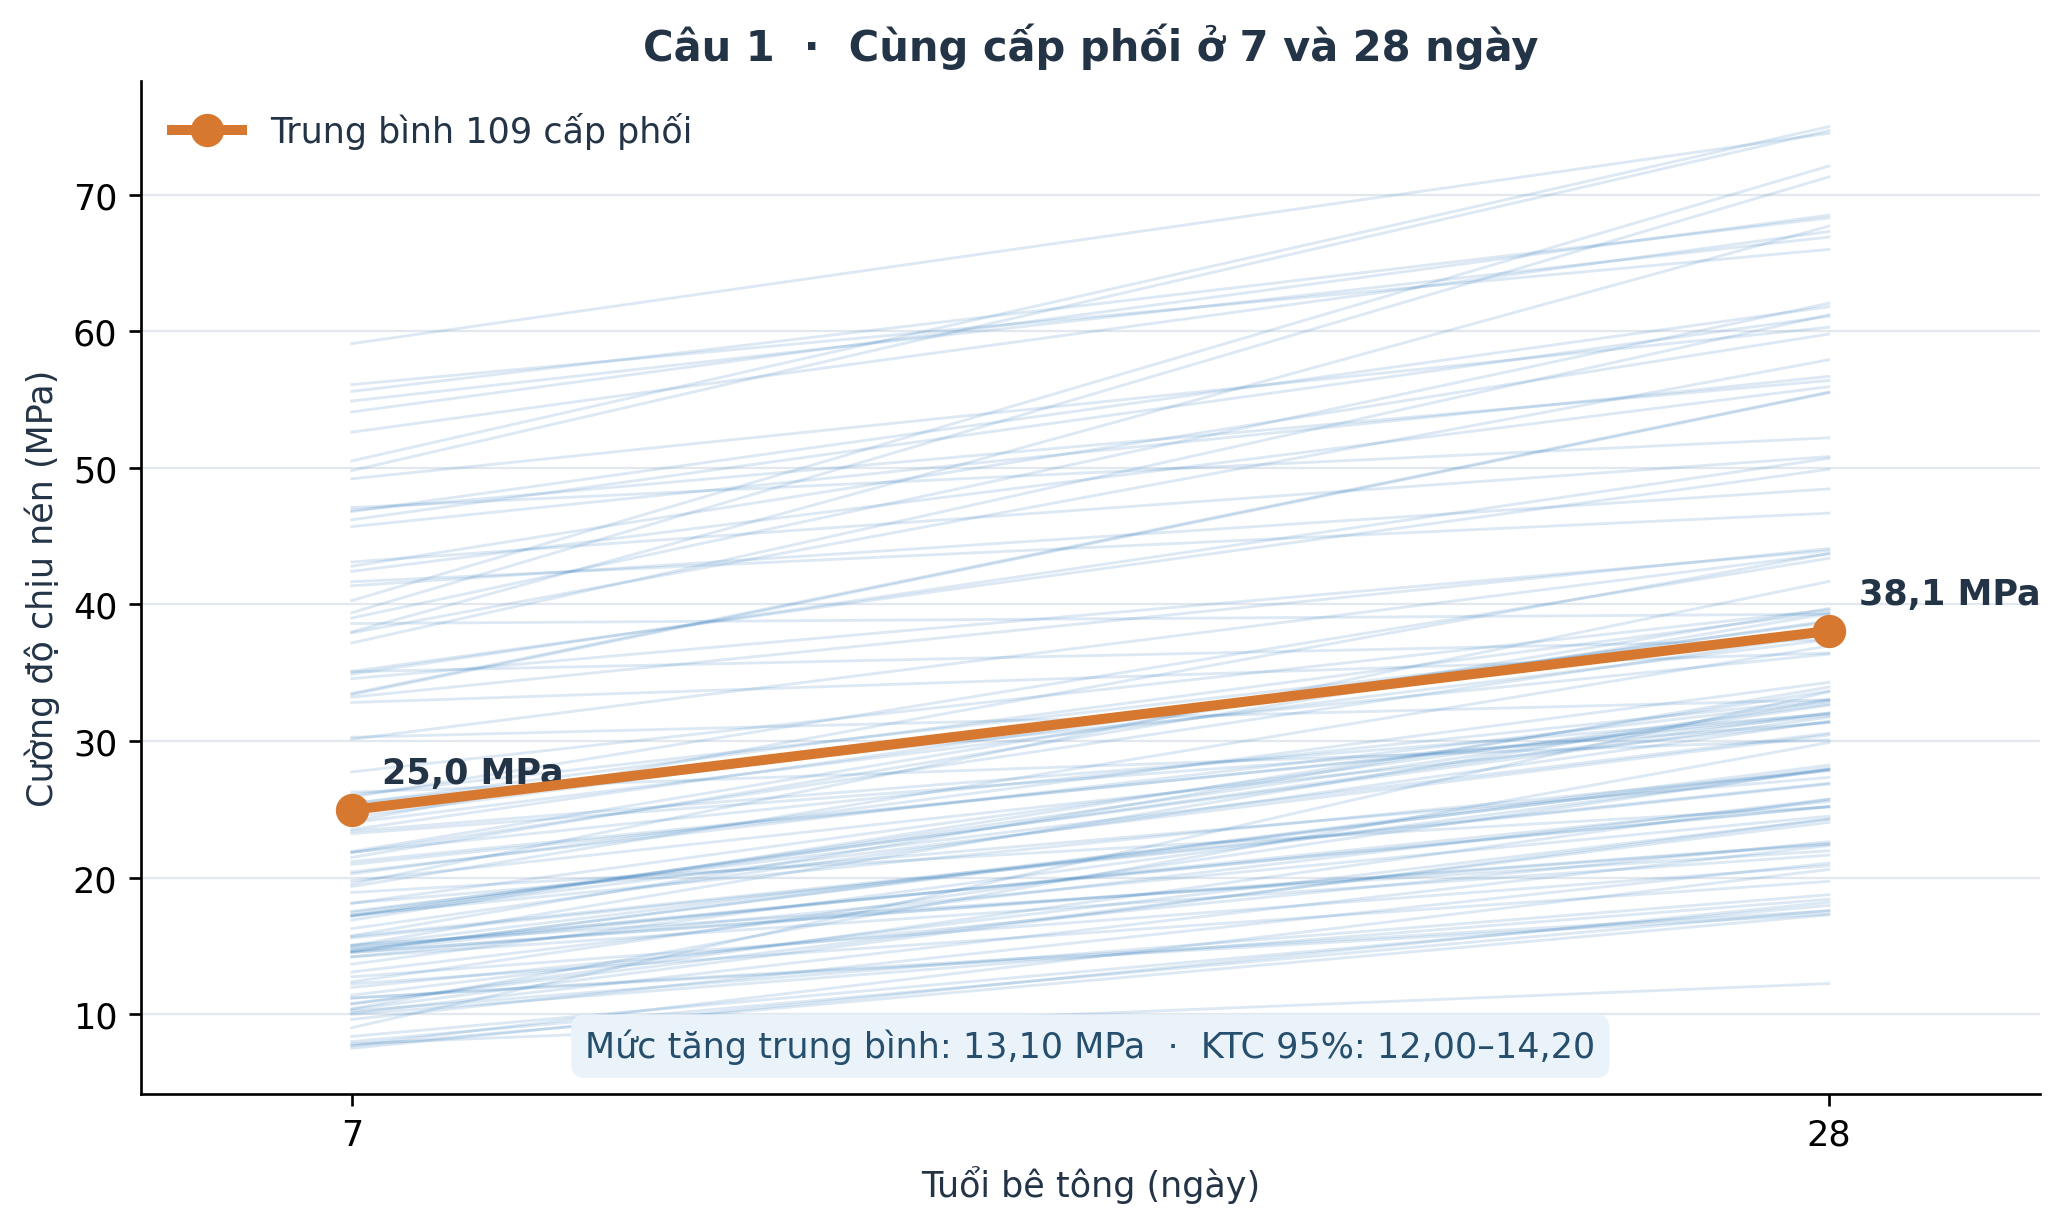

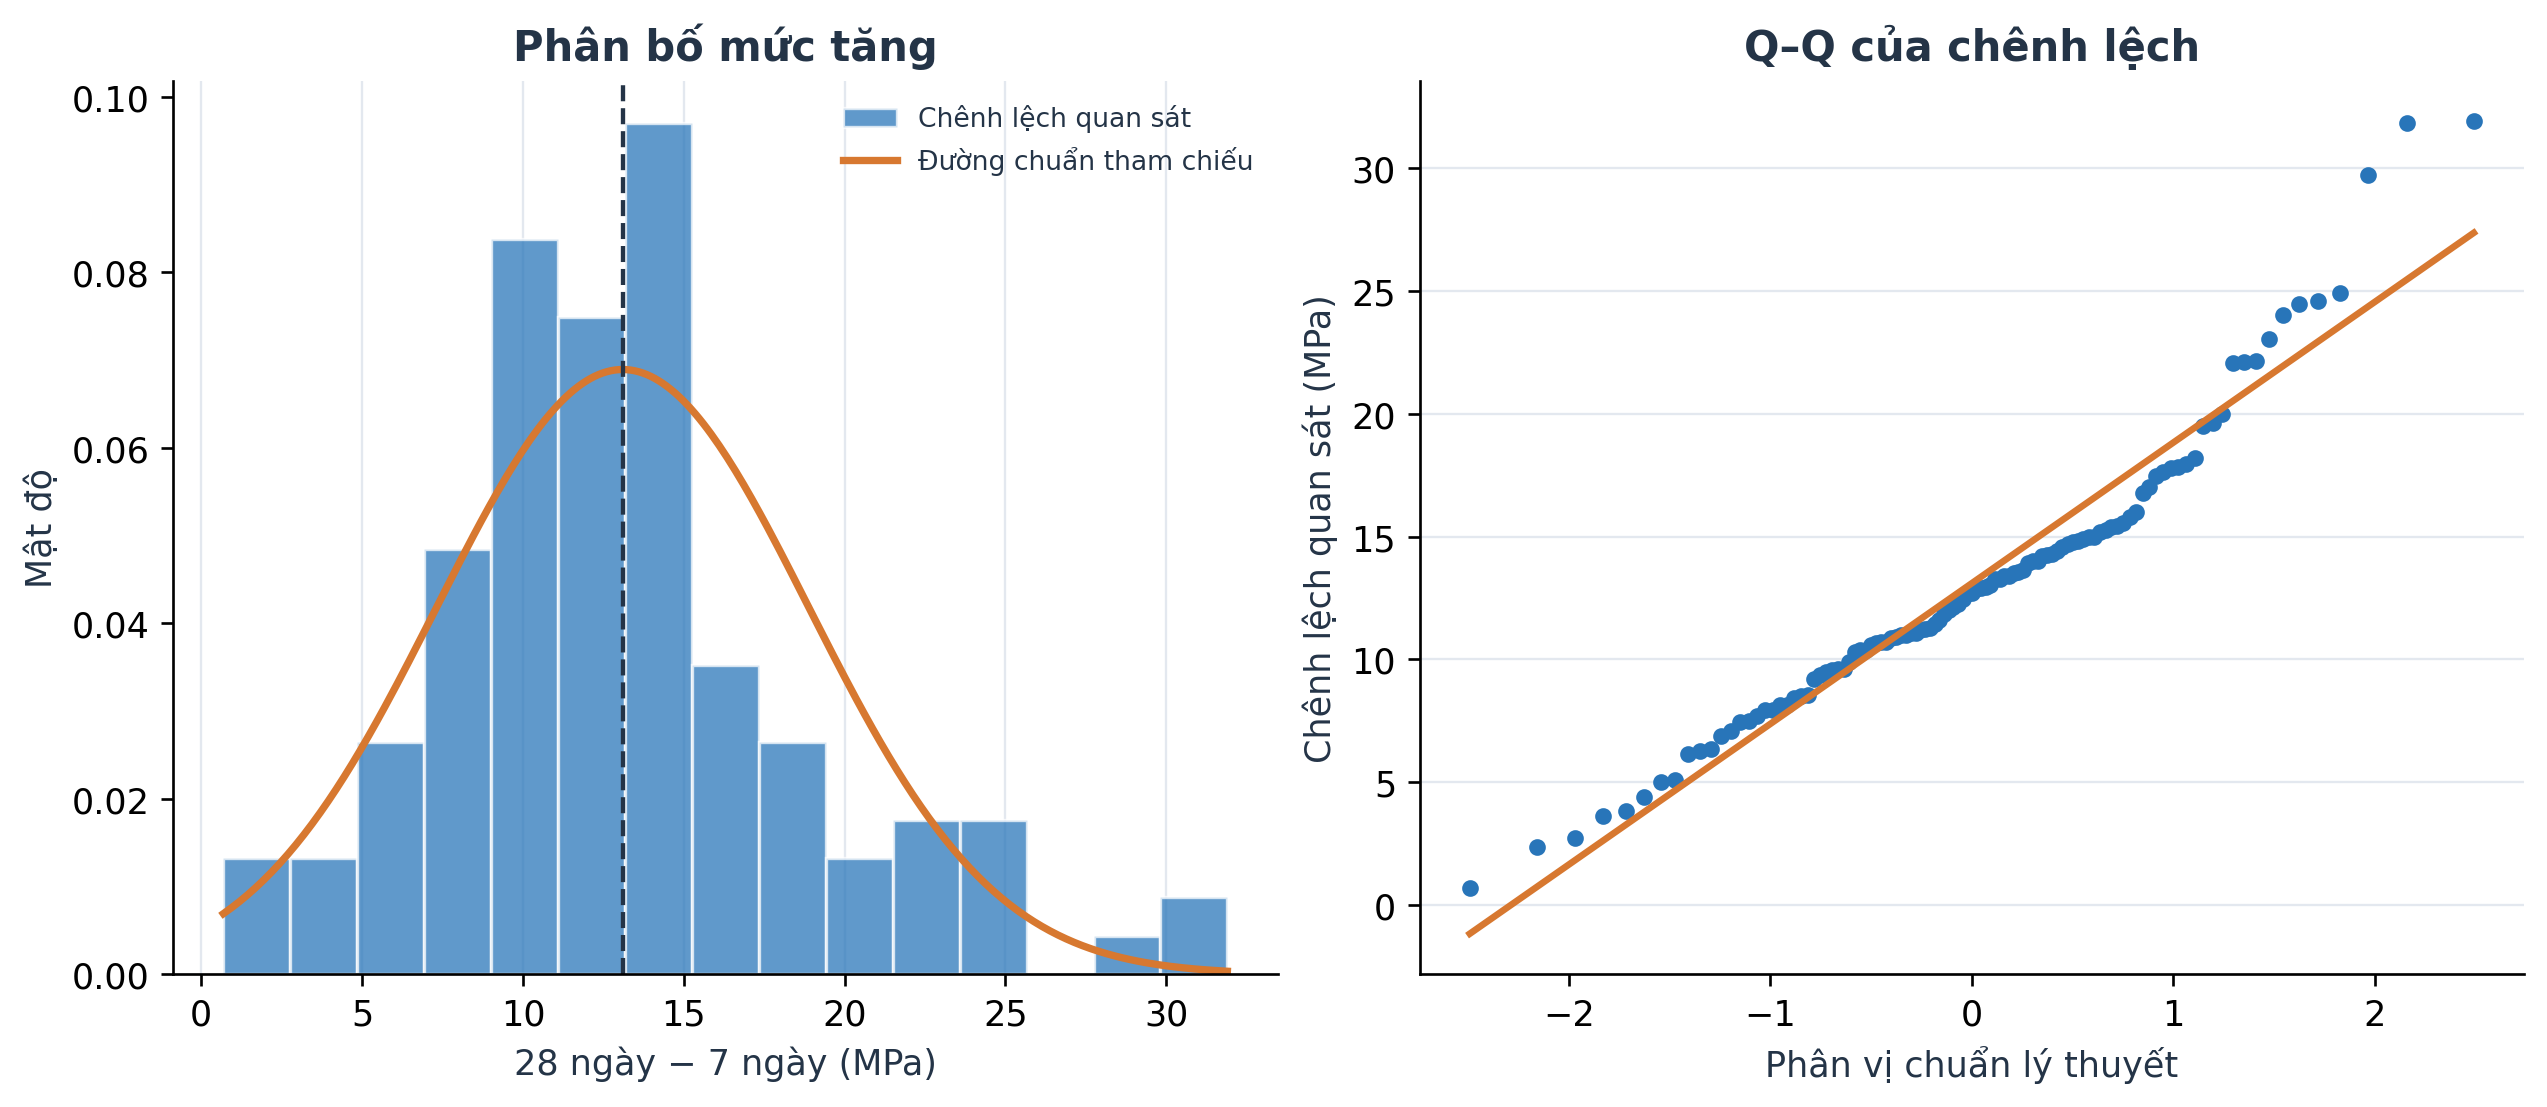

,scm,size,mean,median,std
0,Chỉ xỉ,58,1.759707,1.777488,0.434582
1,Cả hai,10,1.495382,1.559091,0.256849
2,Không SCM,41,1.606163,1.552469,0.394504


In [3]:
display(read_table("cau_1_paired_t").T)
display(Image(filename=str(F / "hinh_3_1_cap_phoi_ghep.png"), width=750))
display(Image(filename=str(F / "hinh_3_1b_chan_doan_chenh_lech.png"), width=900))
display(read_table("ty_so_28_7_theo_nhom"))


**Rút ra từ Hình 3.1 và 3.1b.** Cả 109 cặp đều có cường độ 28 ngày lớn hơn 7 ngày; mức tăng trung bình là **13,10 MPa**, KTC 95% **[12,00; 14,20]**, p < 0,001. Hình chẩn đoán cho thấy chênh lệch không hoàn toàn chuẩn; kiểm định Wilcoxon đối chiếu cũng cho p < 0,001. Kết quả định lượng mức tăng trong **các công thức có đủ hai tuổi**, không phải hệ số dùng cho mọi bê tông.

## 3.4. Câu hỏi 2: Bốn nhóm SCM ở 28 ngày

H₀: μ₁ = μ₂ = μ₃ = μ₄; H₁: ít nhất một trung bình khác. Welch ANOVA là kiểm định tổng thể; Games–Howell đối chiếu sáu cặp. Brown–Forsythe và Shapiro–Wilk được báo ở bảng Welch; ω² là độ lớn mô tả, không phải tác động nhân quả. So sánh theo kiểu SCM (> 0), chưa cô lập tác động của lượng vật liệu.

,nhom,n,mean_mpa,sd_mpa,mean_cement,mean_water,mean_sp
0,Không SCM,66,37.891912,16.738190,379.126616,184.345678,1.719545
1,Chỉ xỉ,95,40.637588,15.447049,255.443684,184.768947,5.275579
2,Chỉ tro bay,65,31.025428,12.692741,240.912923,177.588769,9.488723
3,Cả hai,82,38.401542,12.991294,226.949878,183.043476,8.804268


,0
F,6.879327
df1,3.000000
df2,161.471215
p,0.000217
eta2_descriptive,0.054641
brown_forsythe_p,0.214020
omega2_descriptive,0.045172
shapiro_p_1,0.000145
shapiro_p_2,0.001298
shapiro_p_3,0.334042


,nhom_1,nhom_2,chenhlech_mpa,ci_low,ci_high,p_adjusted
0,Không SCM,Chỉ xỉ,-2.745676,-9.508979,4.017627,0.716590
1,Không SCM,Chỉ tro bay,6.866484,0.111646,13.621322,0.044780
2,Không SCM,Cả hai,-0.509629,-7.050337,6.031078,0.997025
3,Chỉ xỉ,Chỉ tro bay,9.612160,3.809529,15.414791,0.000175
4,Chỉ xỉ,Cả hai,2.236047,-3.309032,7.781126,0.722630
5,Chỉ tro bay,Cả hai,-7.376113,-12.914942,-1.837284,0.003922


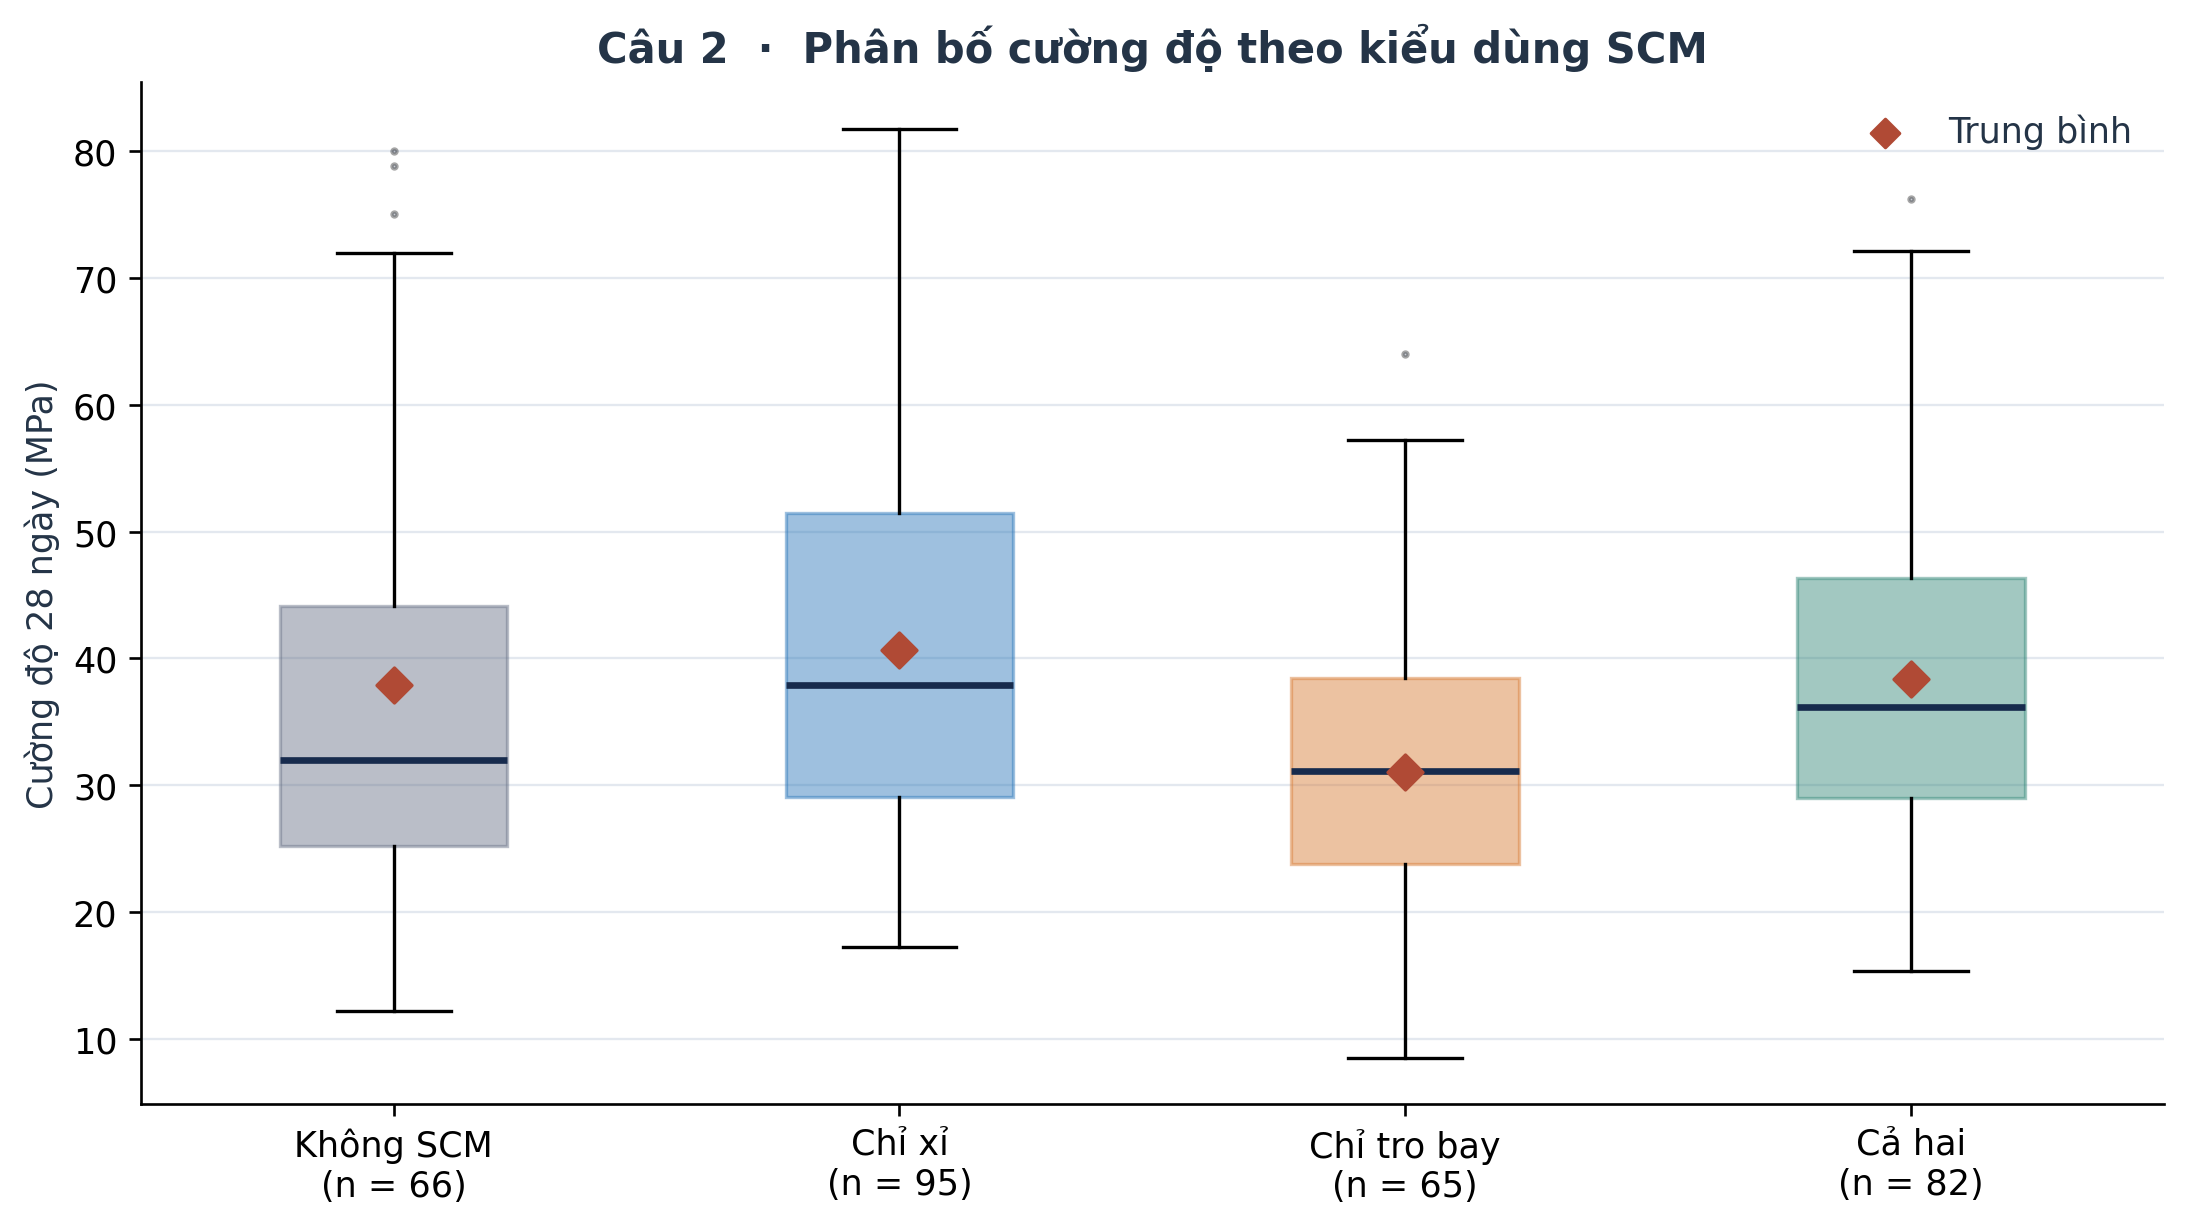

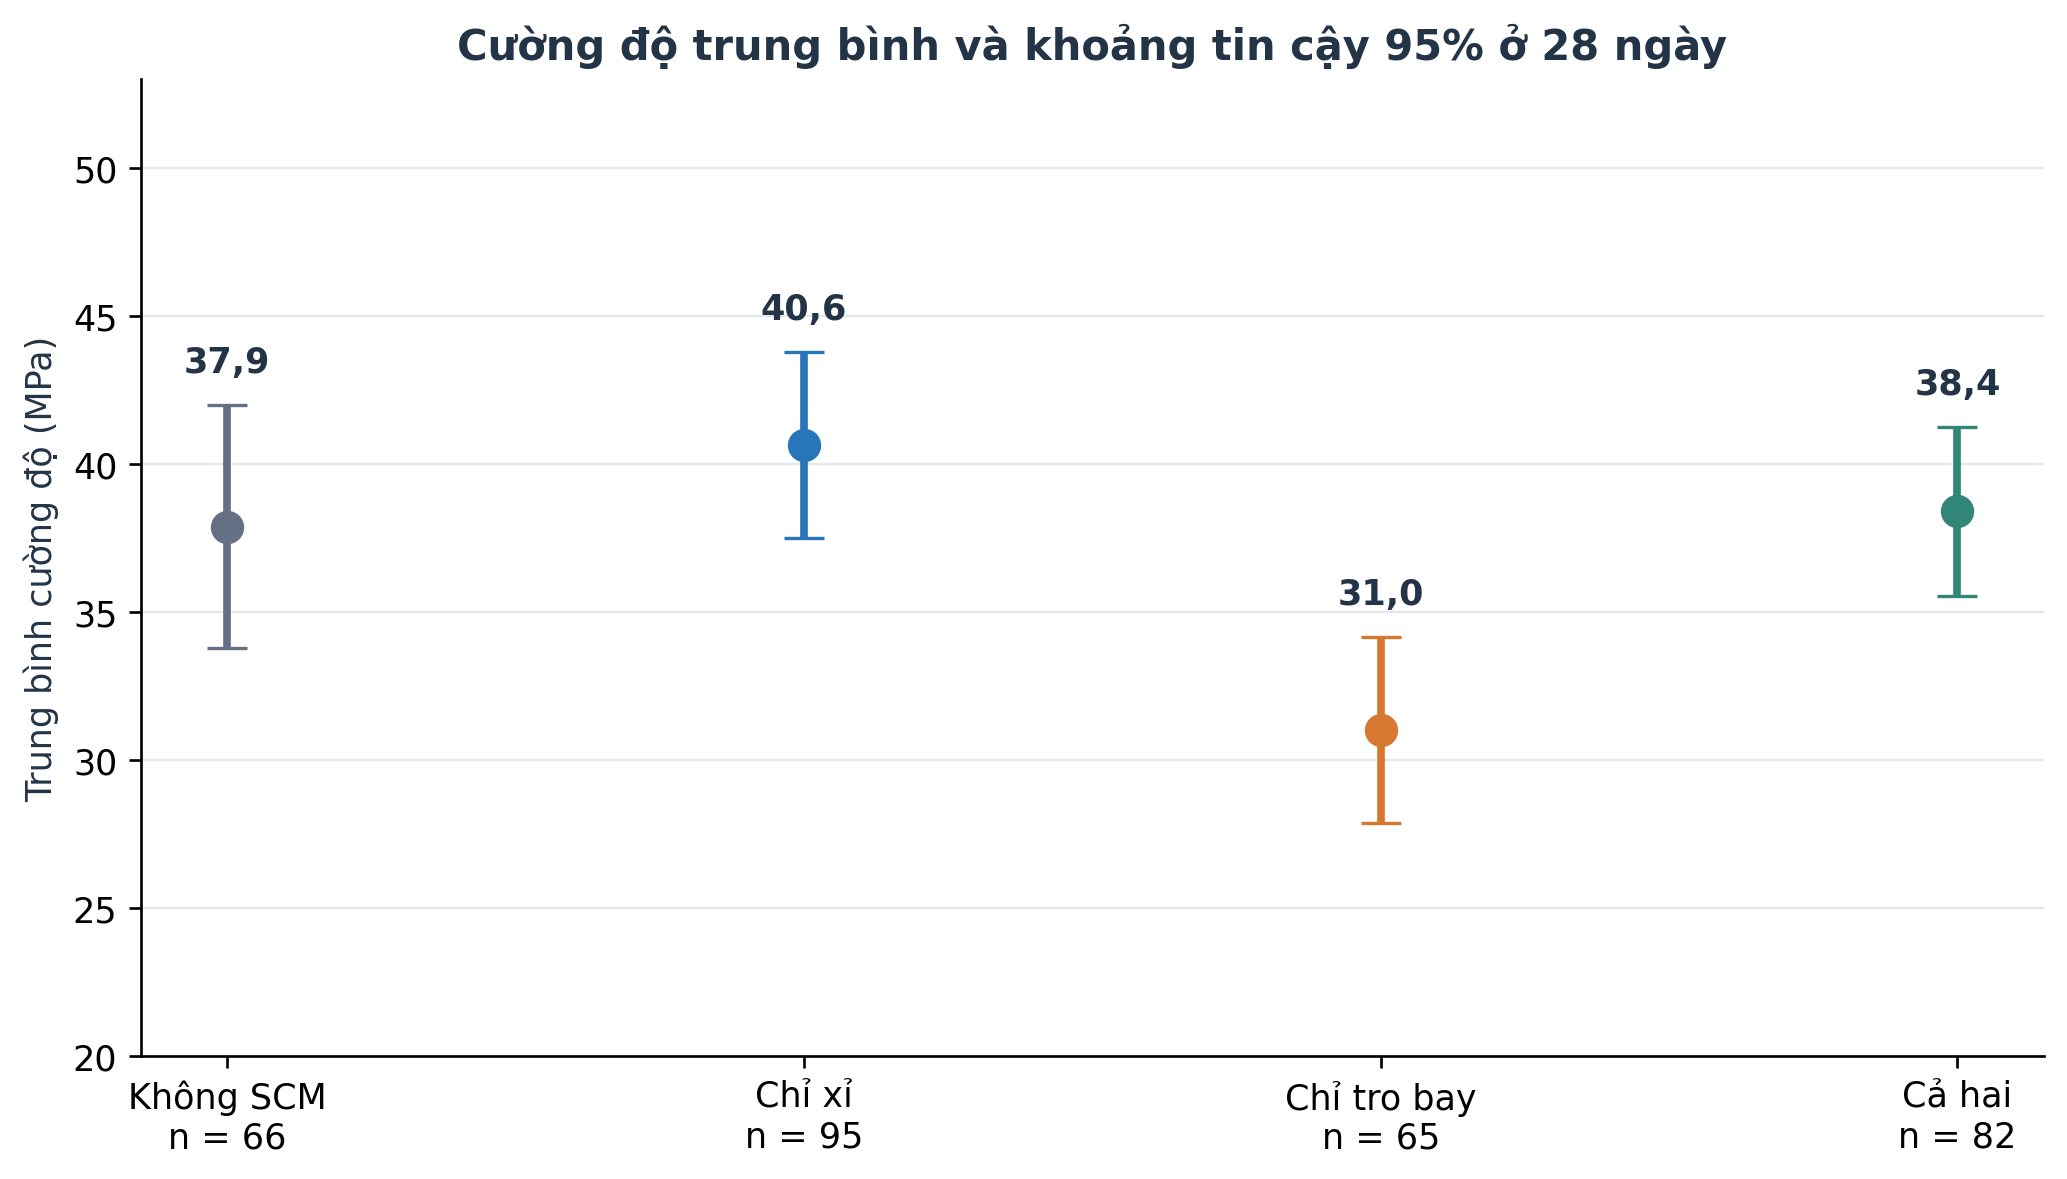

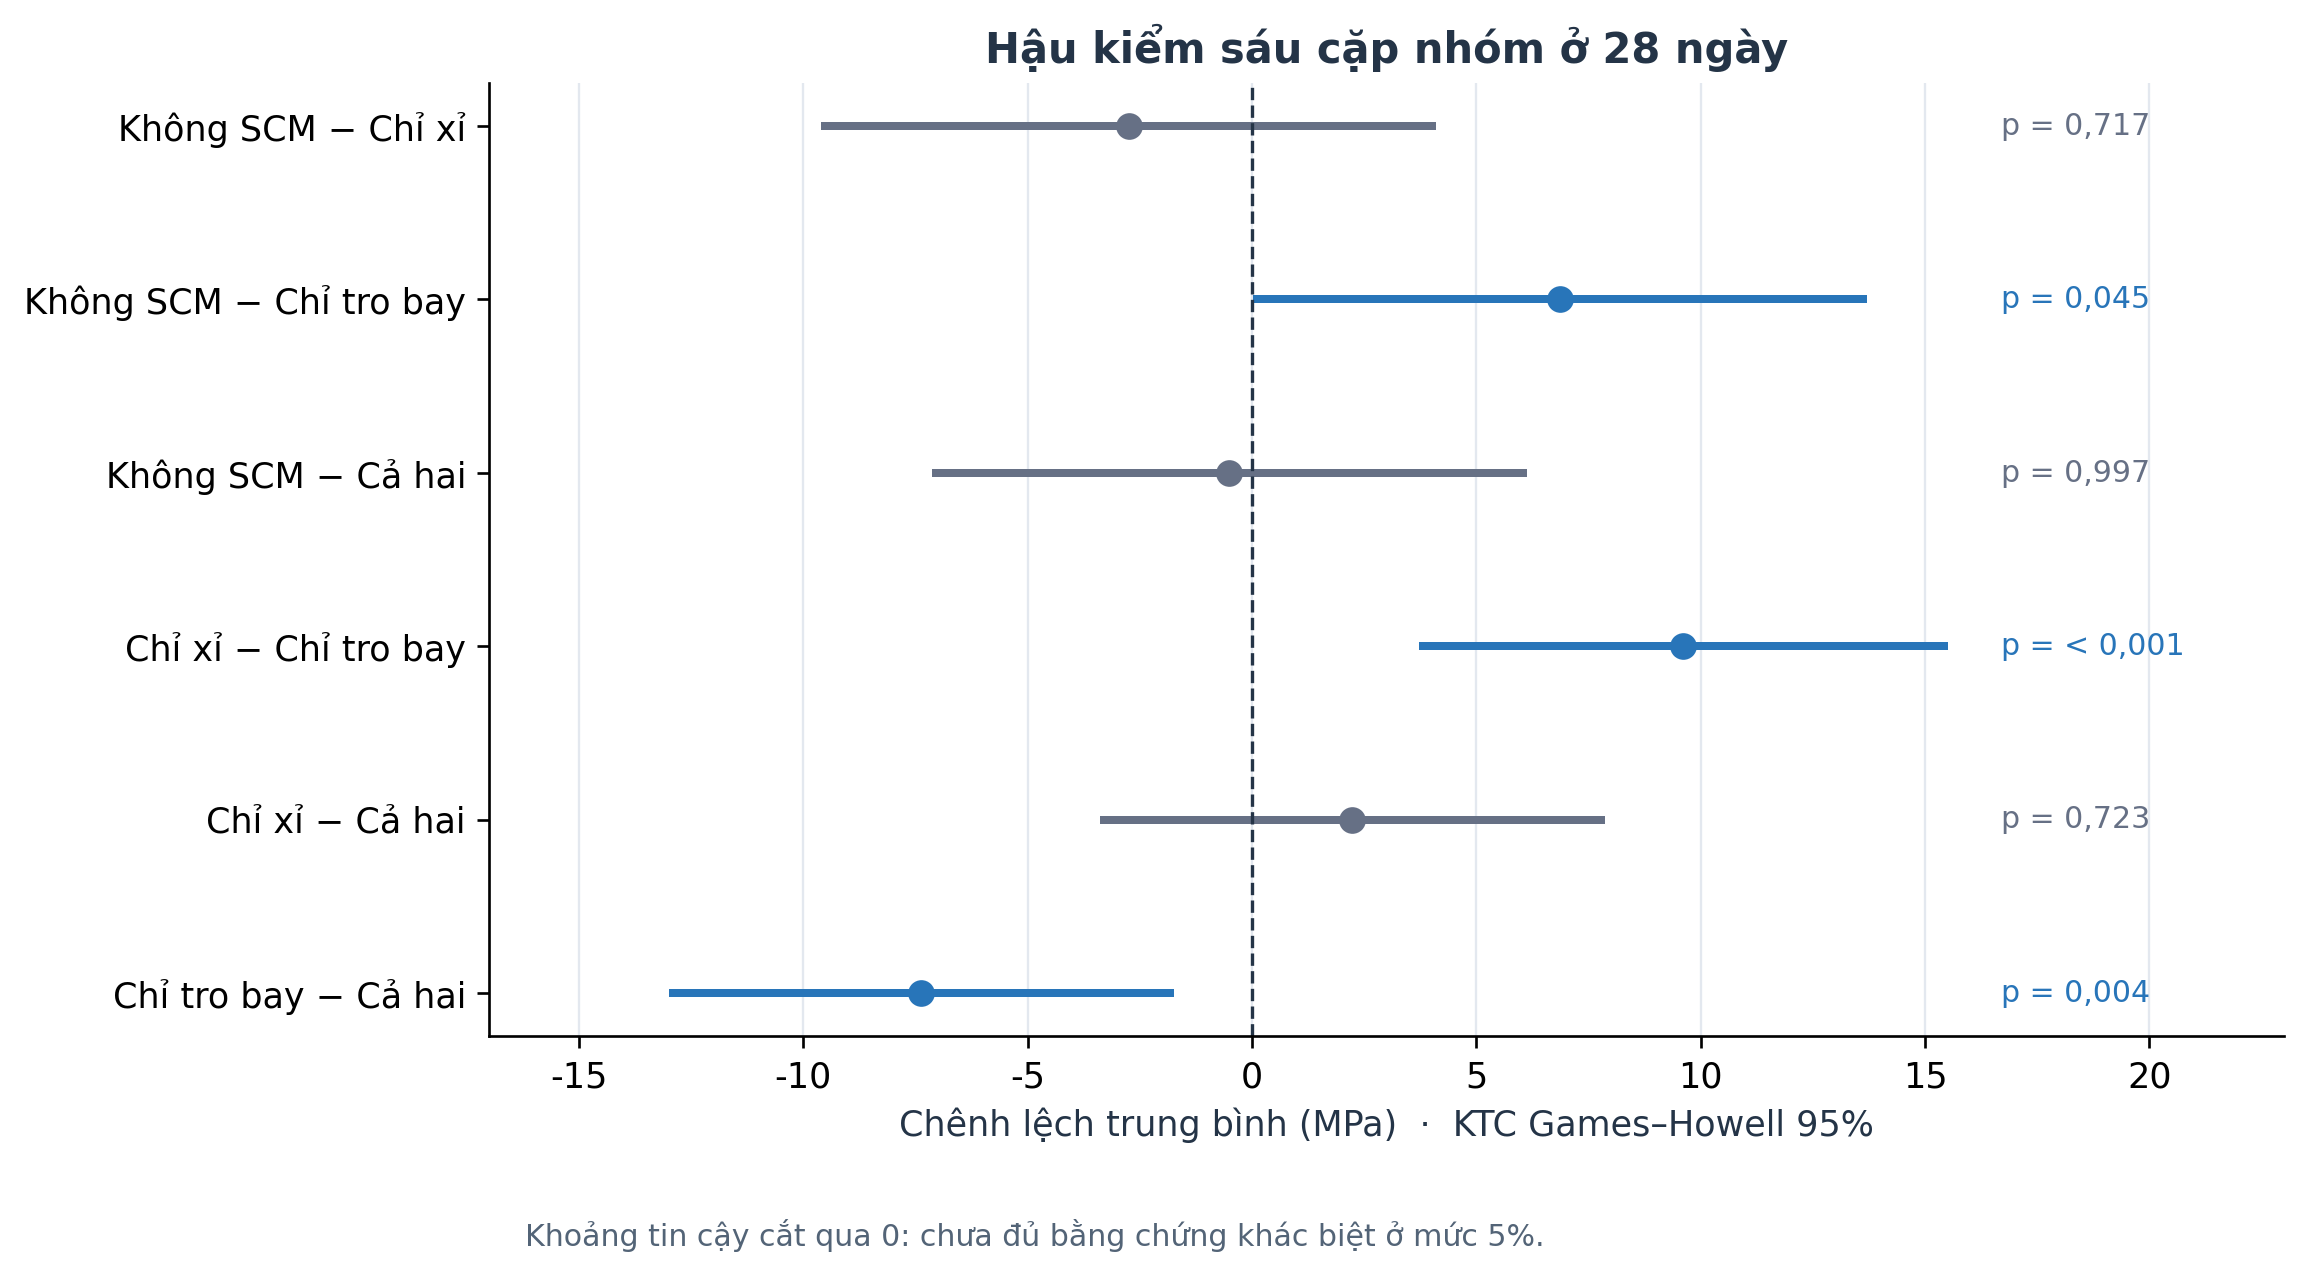

In [4]:
display(read_table("cau_2_mo_ta_nhom"))
display(read_table("cau_2_welch").T)
display(read_table("cau_2_games_howell"))
display(Image(filename=str(F / "hinh_3_2_scm_28.png"), width=800))
display(Image(filename=str(F / "hinh_3_2b_trung_binh_ci.png"), width=800))
display(Image(filename=str(F / "hinh_3_3_games_howell.png"), width=800))


**Rút ra từ Hình 3.2, 3.2b và 3.3.** Các hộp phân bố vẫn chồng lấn; Welch cho thấy có khác biệt tổng thể (**F = 6,88; p < 0,001**), không có nghĩa mọi cặp đều khác. Games–Howell cho bằng chứng rõ ở *Chỉ xỉ − Chỉ tro bay* và *Chỉ tro bay − Cả hai*. Cặp *Không SCM − Chỉ tro bay* ở sát ngưỡng (p = 0,045) cần đọc cùng bảng độ nhạy bên dưới. Bốn nhóm cũng khác về lượng xi măng và phụ gia, nên chưa thể diễn giải theo nhân quả.

## 3.4.1. Độ nhạy với cấp phối gần trùng

Quy tắc gộp chính là complete linkage ngưỡng 1 kg/m³ trên cả bảy vật liệu. Welch tổng thể vẫn có ý nghĩa ở ngưỡng 0; 0,5; 1; 2. Riêng cặp Không SCM − Chỉ tro bay đổi ý nghĩa ở 0,5 (p ≈ 0,071). Các ngưỡng là giả định phân tích, không phải sai số đo được nguồn xác nhận.

In [5]:
display(read_table("do_nhay_gop_cap_phoi"))
display(read_table("anh_xa_cap_phoi_gan_trung").head(12))


,nguong_kg_m3,n_cap_7_28,delta_mpa,n_cap_28,p_welch,p_gh_khong_scm_chi_tro
0,0.0,115,12.873020,417,3.315730e-08,0.003432
1,0.5,112,13.040844,318,1.775993e-04,0.071318
2,1.0,109,13.101063,308,2.174055e-04,0.044780
3,2.0,108,13.151261,304,2.540963e-04,0.037507


,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,recipe_id
0,102.0,153.0,0.0,192.0,0.0,887.0,942.0,197
1,108.3,162.4,0.0,203.5,0.0,938.2,849.0,199
2,116.0,173.0,0.0,192.0,0.0,909.8,891.9,202
3,122.6,183.9,0.0,203.5,0.0,958.2,800.1,34
4,132.0,206.5,160.9,178.9,5.5,866.9,735.6,60
5,132.0,207.0,161.0,179.0,5.0,867.0,736.0,60
6,133.0,200.0,0.0,192.0,0.0,927.4,839.2,200
7,133.0,210.0,0.0,196.0,3.0,949.0,795.0,39
8,133.1,210.2,0.0,195.7,3.1,949.4,795.3,39
9,134.7,0.0,165.7,180.2,10.0,961.0,804.9,240


**Đọc bảng độ nhạy.** Welch tổng thể vẫn có p < 0,001 ở bốn ngưỡng gộp. Riêng p Games–Howell của *Không SCM − Chỉ tro bay* đổi từ **0,003 đến 0,071**; vì vậy không xem kết luận về cặp này là vững theo cách gộp cấp phối. Ngưỡng 1 kg/m³ là quy tắc phân tích, chưa được nguồn dữ liệu xác nhận là sai số đo.

## 3.5. Kiểm tra vùng xi măng chung

Xi măng trung bình ở nhóm Không SCM cao hơn nhiều nhóm có SCM. Khoảng 220–340 kg/m³ là kiểm tra chồng lấn sau khi xem dữ liệu: có 120 cấp phối thuộc bốn nhóm. Bảng có KTC 95% theo từng nhóm. Thứ hạng trung bình đổi chiều; vì nước và phụ gia còn khác nhau, không xem đây là ước lượng tác động nhân quả hoặc phép ghép tương đương hoàn toàn.

,nhom,n,mean_strength,ci_low,ci_high,mean_cement,mean_water,mean_sp
0,Không SCM,29,26.091920,23.858310,28.325529,296.491034,188.774072,0.386207
1,Chỉ xỉ,37,45.248325,40.956609,49.540041,289.777027,185.101351,4.677027
2,Chỉ tro bay,32,35.080948,32.102532,38.059365,275.190625,182.825000,8.895531
3,Cả hai,22,45.076656,39.776946,50.376366,278.456364,185.218182,9.525000


,0
F,3.196374e+01
df1,3.000000e+00
df2,5.811358e+01
p,2.469327e-12


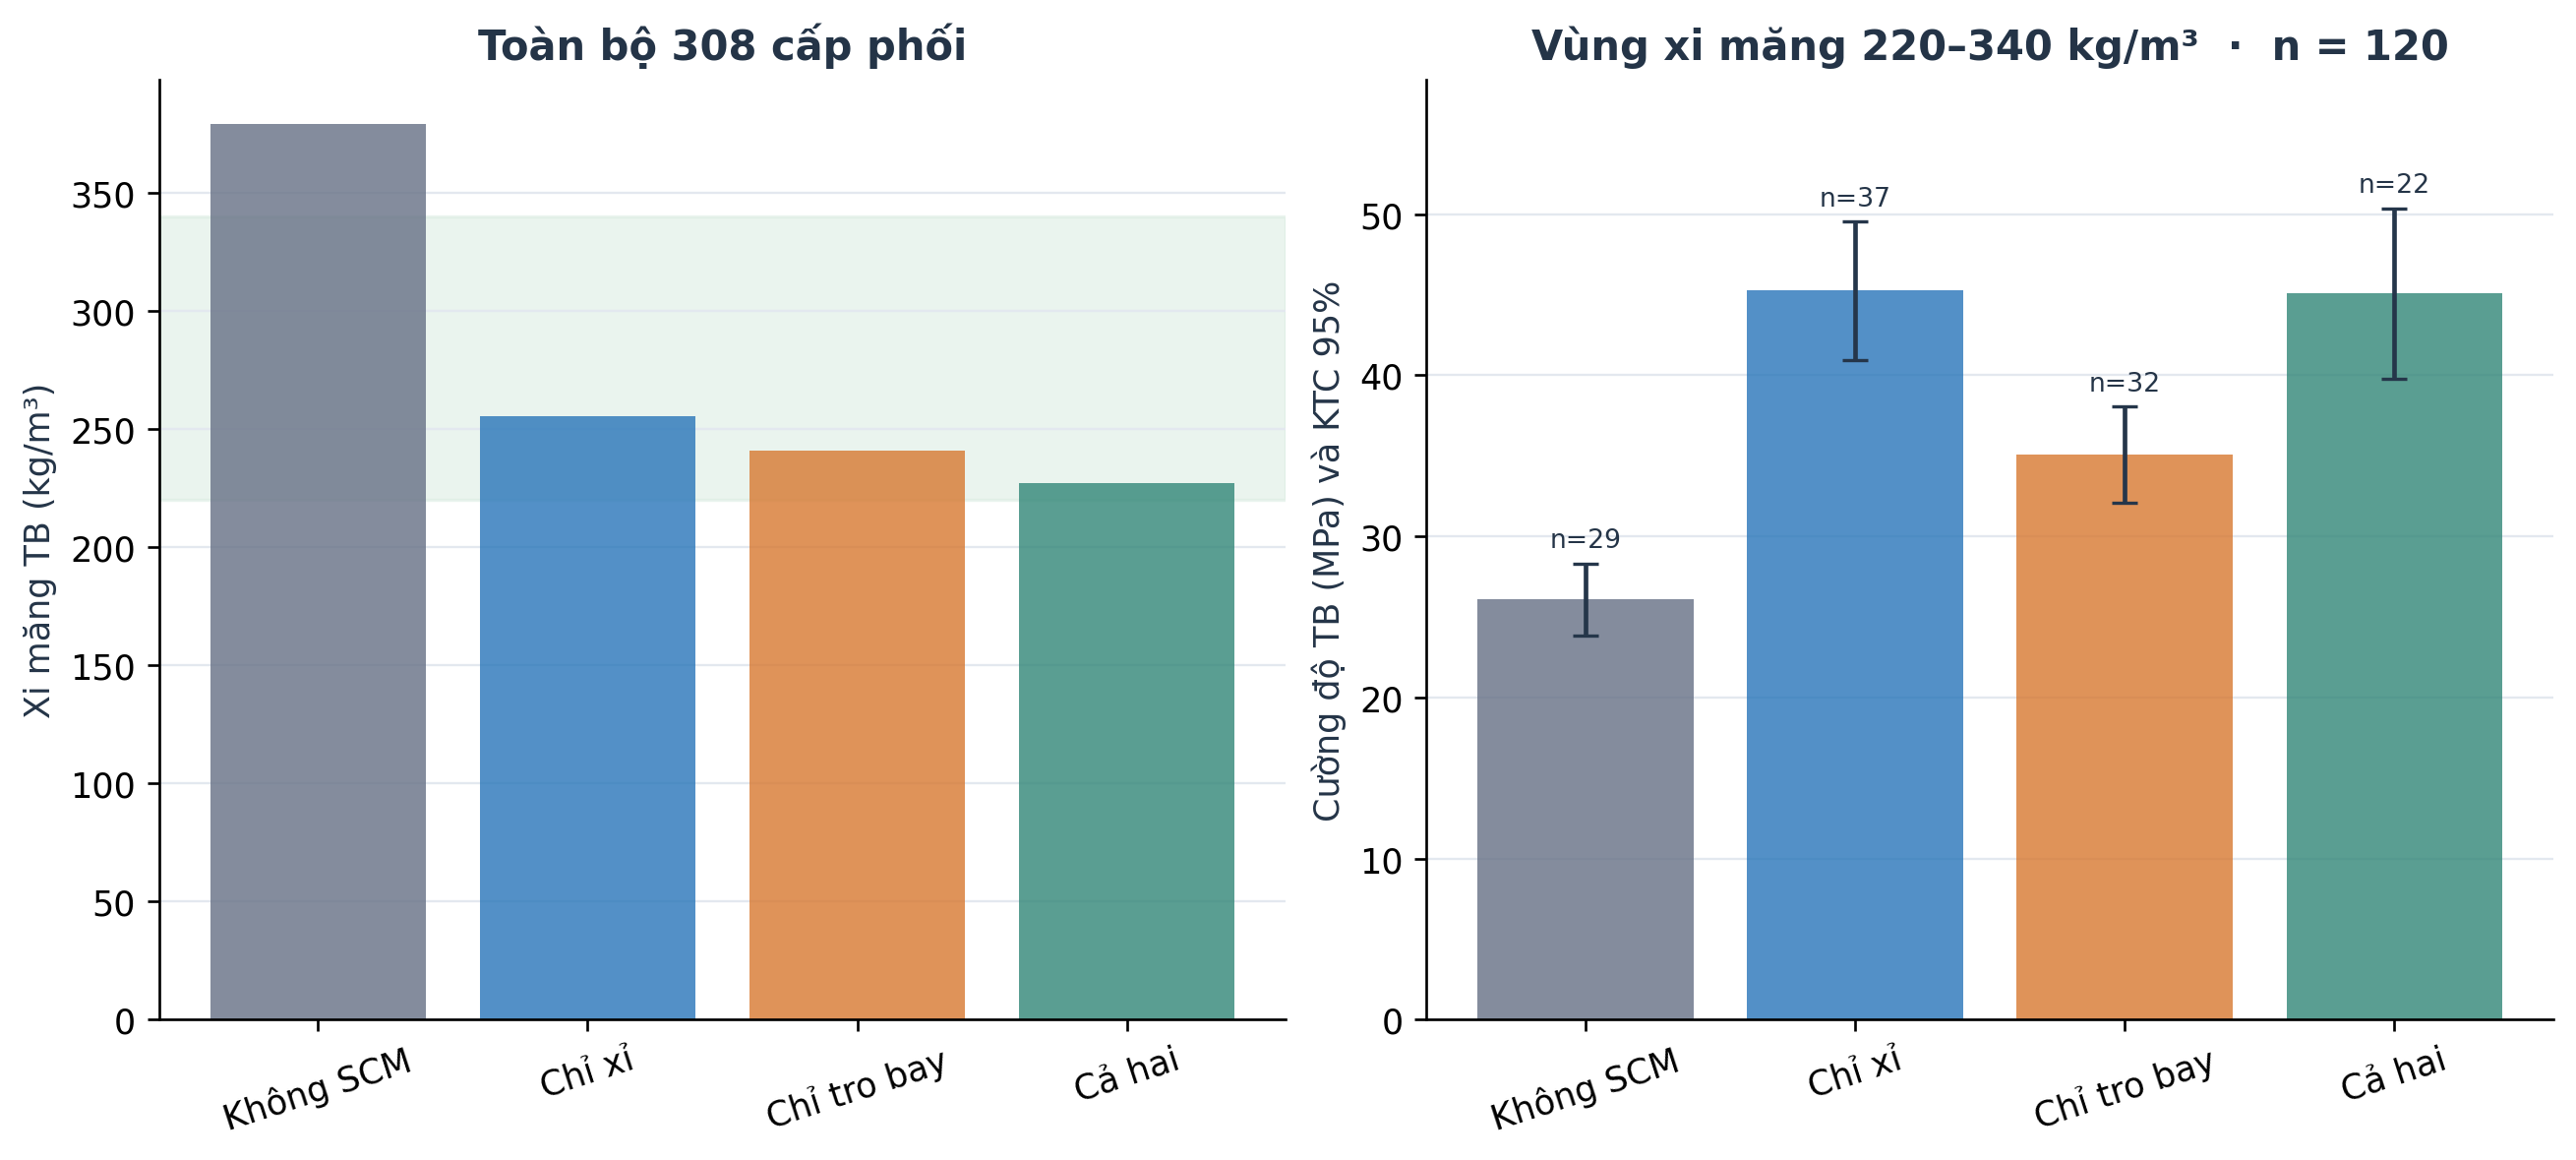

In [6]:
display(read_table("cau_2_vung_xi_mang_chung"))
display(read_table("cau_2_welch_vung_chung").T)
display(Image(filename=str(F / "hinh_3_4_kiem_tra_xi_mang.png"), width=900))


**Rút ra từ Hình 3.4.** Trong vùng xi măng chung, nhóm *Không SCM* có cường độ trung bình **26,09 MPa**, thấp hơn các nhóm SCM (**35,08–45,25 MPa**), đảo thứ hạng so với so sánh trên toàn mẫu. Các thanh KTC cho biết độ bất định của trung bình từng nhóm. Vùng 220–340 kg/m³ được chọn sau khi xem dữ liệu, và lượng nước/phụ gia vẫn khác nhau: đây là dấu hiệu nhiễu mạnh để tiếp tục xem xét, **không phải** hiệu quả riêng của SCM. Welch ở tập con là phép thăm dò, không phải một kiểm định xác nhận thứ hai.

## 3.6. Chi-square: SCM và việc dùng phụ gia siêu dẻo

Hai biến phân loại sẵn có: kiểu SCM và `superplasticizer > 0`. H₀: chúng độc lập. Kết quả χ²(3) = 136,31, Cramér V = 0,665. Đây là kiểm tra bổ sung về cấu trúc cấp phối, không phải phép kiểm định thứ ba về cường độ.

,scm,Không,Có
0,Không SCM,51,15
1,Chỉ xỉ,45,50
2,Chỉ tro bay,1,64
3,Cả hai,1,81


,0
chi2,1.363066e+02
df,3.000000e+00
p,2.364574e-29
min_expected,2.068182e+01
cramer_v,6.652472e-01


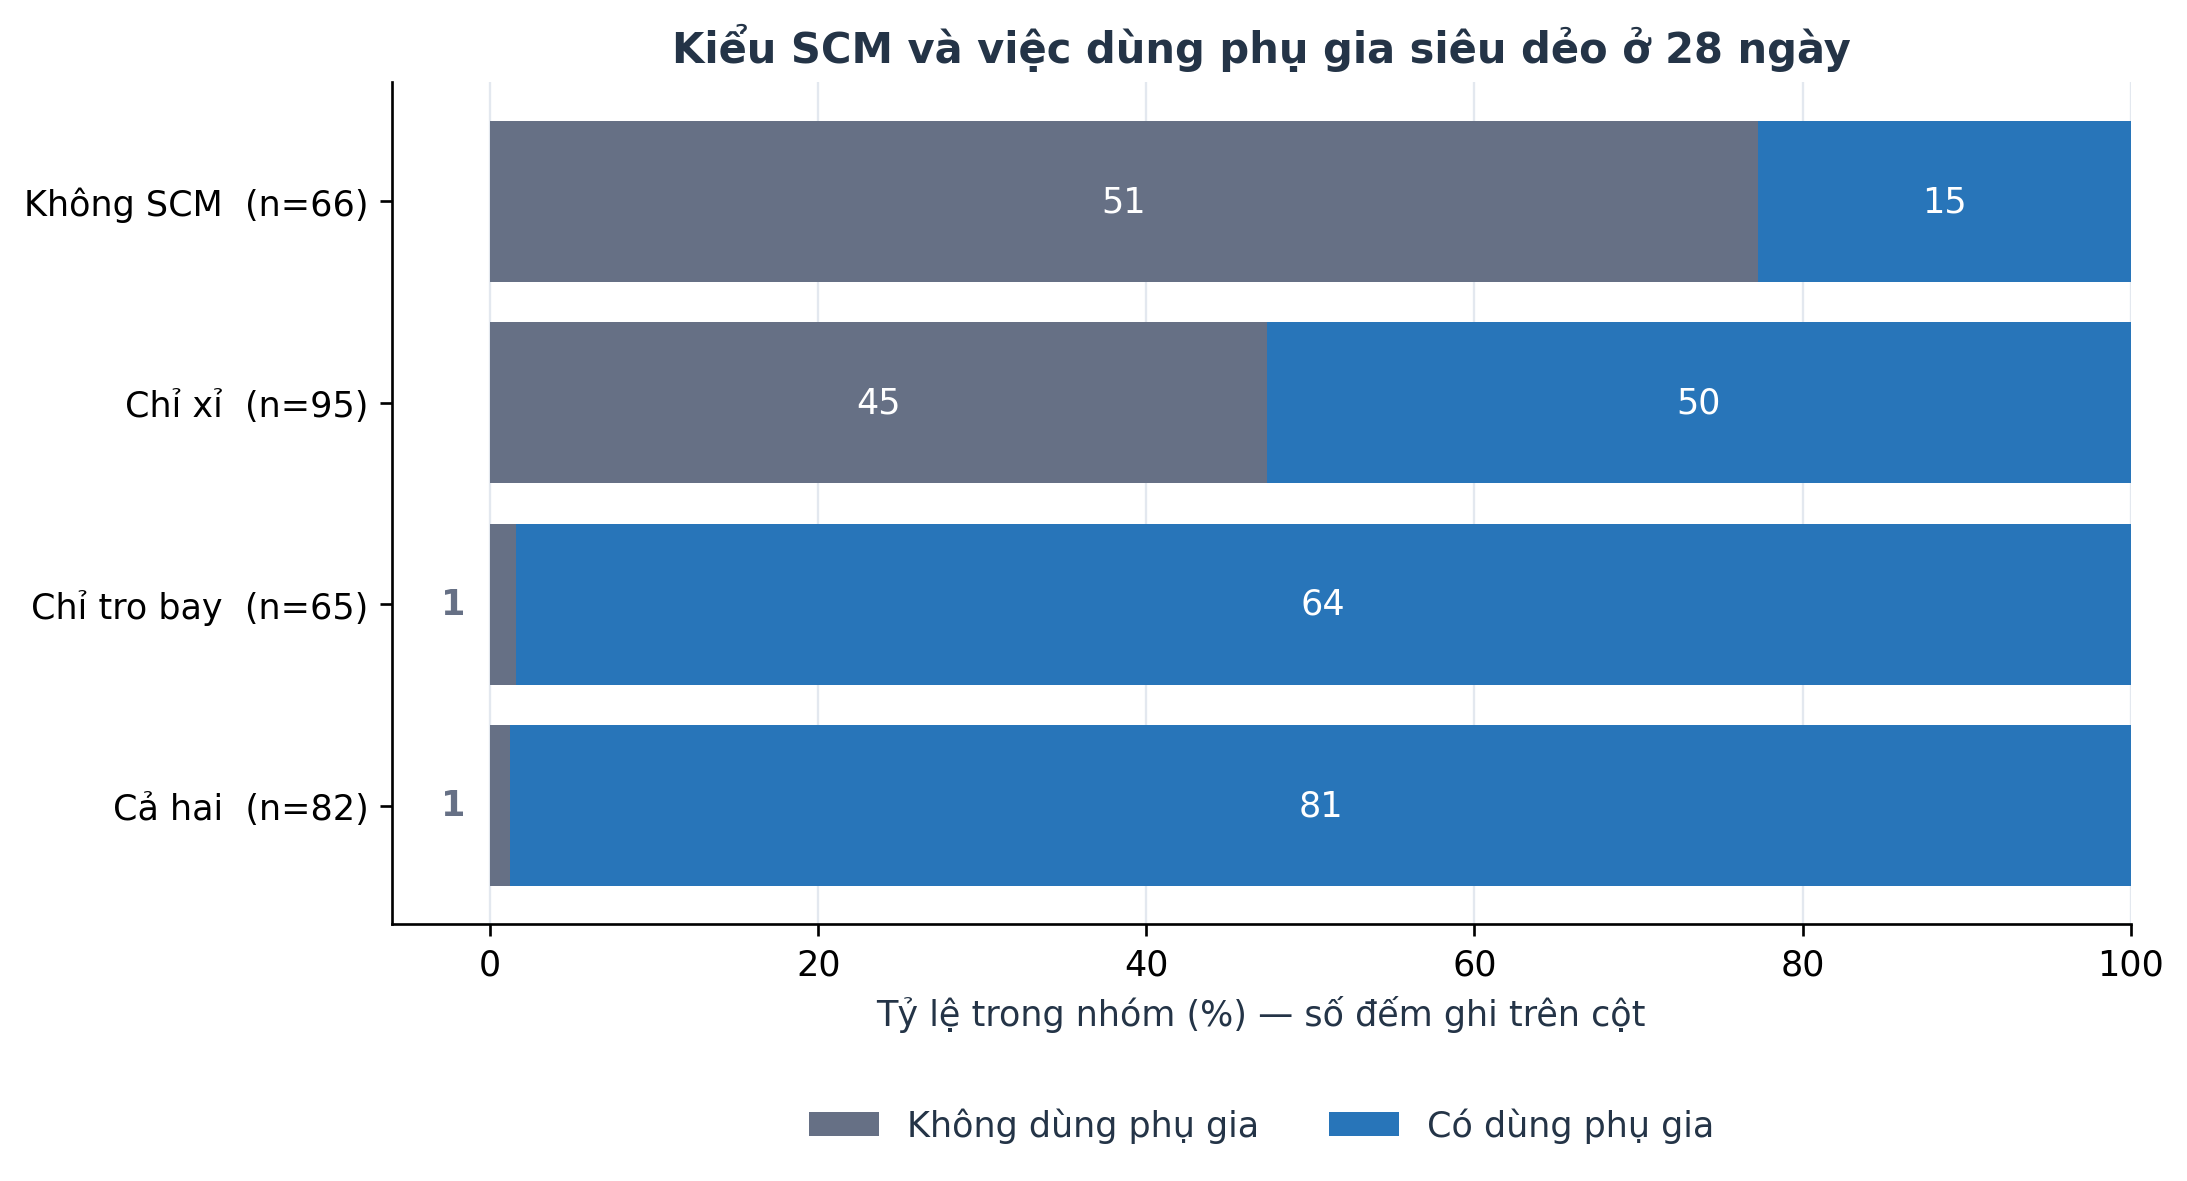

In [7]:
display(read_table("chi_square_bang_cheo"))
display(read_table("chi_square_ket_qua").T)
display(Image(filename=str(F / "hinh_3_5_chi_square.png"), width=800))


**Rút ra từ Hình 3.5.** Tỷ lệ dùng phụ gia siêu dẻo tăng từ **22,7%** ở nhóm Không SCM lên **98,5–98,8%** ở hai nhóm có tro bay. Chi-square có p < 0,001 và Cramér V = 0,665, cho thấy cấu trúc cấp phối khác nhau giữa nhóm; hình này không kiểm định tác động của phụ gia lên cường độ.

## Kiểm tra đầu ra

Mọi hình cần giải mã được và có dung lượng khác 0. `analysis/reporting.py` kiểm tra tính nhất quán của bảng, hình và CSV đầu vào. Với CSV khác, cần chạy lại script và cập nhật diễn giải trong Markdown/Word/PDF trước khi nộp.

In [8]:
from PIL import Image as PILImage
for path in sorted(F.glob("*.png")):
    with PILImage.open(path) as im:
        im.load()
        print(path.name, im.size, path.stat().st_size, "bytes — OK")
assert len(list(F.glob("*.png"))) == 7


hinh_3_1_cap_phoi_ghep.png (2064, 1227) 465696 bytes — OK
hinh_3_1b_chan_doan_chenh_lech.png (2547, 1107) 168806 bytes — OK
hinh_3_2_scm_28.png (2187, 1227) 88173 bytes — OK
hinh_3_2b_trung_binh_ci.png (2067, 1179) 86339 bytes — OK
hinh_3_3_games_howell.png (2307, 1276) 132901 bytes — OK
hinh_3_4_kiem_tra_xi_mang.png (2619, 1179) 119267 bytes — OK
hinh_3_5_chi_square.png (2187, 1181) 97789 bytes — OK
